# EDA — BTC 5-Minute Up/Down Markets (Polymarket)

Exploratory analysis of ~4 000 resolved BTC 5-minute binary prediction markets.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load & inspect

In [2]:
df = pd.read_csv("../data/processed/btc_5m_markets.csv", parse_dates=["event_datetime", "date"])
print(f"Shape: {df.shape}")
df.head()

Shape: (4033, 14)


,slug,event_timestamp,event_datetime,date,hour,minute,day_of_week,winner,winner_binary,up_final_price,down_final_price,volume,closed,last_trade_price
0,btc-updown-5m-1771867800,1771867800,2026-02-23 17:30:00+00:00,2026-02-23,17,30,Monday,Down,0,0.0,1.0,150736.786424,True,0.010
1,btc-updown-5m-1771868100,1771868100,2026-02-23 17:35:00+00:00,2026-02-23,17,35,Monday,Down,0,0.0,1.0,130727.042429,True,0.010
2,btc-updown-5m-1771868400,1771868400,2026-02-23 17:40:00+00:00,2026-02-23,17,40,Monday,Up,1,1.0,0.0,135099.478512,True,0.999
3,btc-updown-5m-1771868700,1771868700,2026-02-23 17:45:00+00:00,2026-02-23,17,45,Monday,Down,0,0.0,1.0,143793.303297,True,0.001
4,btc-updown-5m-1771869000,1771869000,2026-02-23 17:50:00+00:00,2026-02-23,17,50,Monday,Up,1,1.0,0.0,153598.742838,True,0.999


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4033 entries, 0 to 4032
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   slug              4033 non-null   object             
 1   event_timestamp   4033 non-null   int64              
 2   event_datetime    4033 non-null   datetime64[ns, UTC]
 3   date              4033 non-null   datetime64[ns]     
 4   hour              4033 non-null   int64              
 5   minute            4033 non-null   int64              
 6   day_of_week       4033 non-null   object             
 7   winner            4033 non-null   object             
 8   winner_binary     4033 non-null   int64              
 9   up_final_price    4033 non-null   float64            
 10  down_final_price  4033 non-null   float64            
 11  volume            4033 non-null   float64            
 12  closed            4033 non-null   bool               
 13  las

In [4]:
df.describe()

,event_timestamp,date,hour,minute,winner_binary,up_final_price,down_final_price,volume,last_trade_price
count,4.033000e+03,4033,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000,4033.000000
mean,1.772473e+09,2026-03-02 05:32:25.053309952,11.501364,27.500620,0.497396,0.497396,0.502604,89870.915965,0.497405
min,1.771868e+09,2026-02-23 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000
25%,1.772170e+09,2026-02-27 00:00:00,6.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.010000
50%,1.772473e+09,2026-03-02 00:00:00,12.000000,30.000000,0.000000,0.000000,1.000000,100499.261347,0.480000
75%,1.772775e+09,2026-03-06 00:00:00,17.000000,40.000000,1.000000,1.000000,1.000000,139131.805928,0.990000
max,1.773077e+09,2026-03-09 00:00:00,23.000000,55.000000,1.000000,1.000000,1.000000,714113.221655,0.999000
std,3.493113e+05,NaN,6.922728,17.260308,0.500055,0.500055,0.500055,73339.608683,0.468382


In [5]:
df.isnull().sum()

slug                0
event_timestamp     0
event_datetime      0
date                0
hour                0
minute              0
day_of_week         0
winner              0
winner_binary       0
up_final_price      0
down_final_price    0
volume              0
closed              0
last_trade_price    0
dtype: int64

## 2. Outcome distribution (Up vs Down)

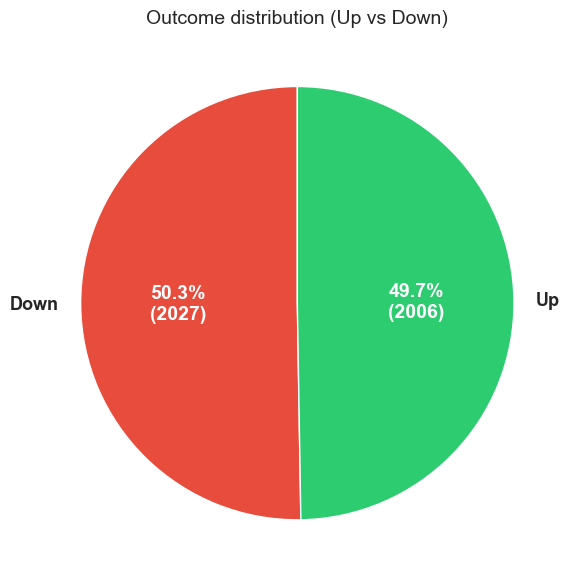

In [18]:
winner_counts = df["winner"].value_counts()

colors = {"Up": "#2ecc71", "Down": "#e74c3c"}

def make_label(pct, counts=winner_counts):
    absolute = int(round(pct / 100.0 * counts.sum()))
    return f"{pct:.1f}%\n({absolute})"

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    winner_counts,
    labels=winner_counts.index,
    colors=[colors[w] for w in winner_counts.index],
    autopct=lambda pct: make_label(pct),
    startangle=90,
    pctdistance=0.55,
    textprops={"fontsize": 13, "fontweight": "bold"},
)
for t in autotexts:
    t.set_color("white")
    t.set_fontsize(14)

ax.set_title("Outcome distribution (Up vs Down)", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Volume analysis

Total volume traded: $362,449,404
Mean per market:     $89,871
Median per market:   $100,499


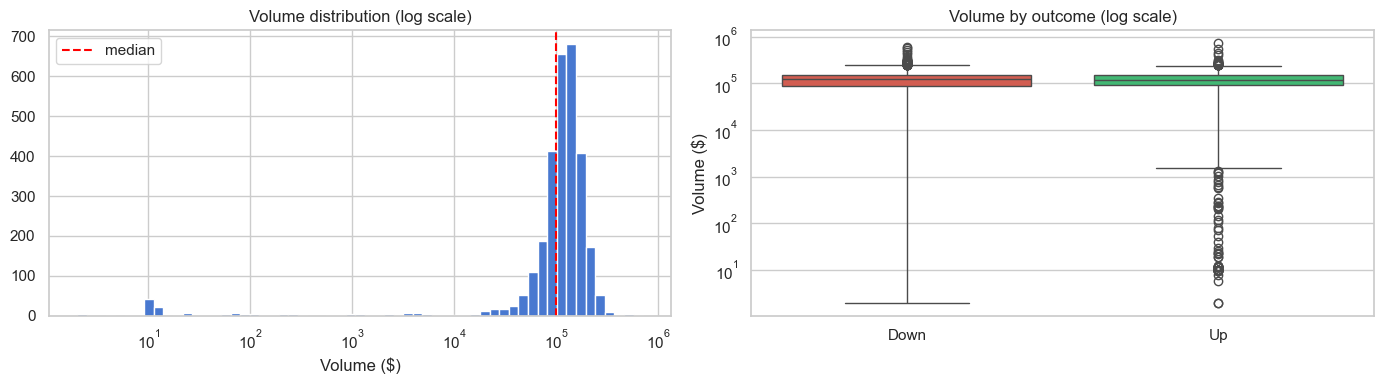

In [23]:
import numpy as np

print(f"Total volume traded: ${df['volume'].sum():,.0f}")
print(f"Mean per market:     ${df['volume'].mean():,.0f}")
print(f"Median per market:   ${df['volume'].median():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vol_positive = df["volume"][df["volume"] > 0]
log_bins = np.logspace(np.log10(vol_positive.min()), np.log10(vol_positive.max()), 60)
axes[0].hist(vol_positive, bins=log_bins, edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Volume distribution (log scale)")
axes[0].set_xlabel("Volume ($)")
axes[0].axvline(df["volume"].median(), color="red", ls="--", label="median")
axes[0].legend()

df_pos = df[df["volume"] > 0]
sns.boxplot(data=df_pos, x="winner", y="volume", hue="winner", ax=axes[1],
            palette={"Up": "#2ecc71", "Down": "#e74c3c"}, legend=False)
axes[1].set_yscale("log")
axes[1].set_title("Volume by outcome (log scale)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Volume ($)")

plt.tight_layout()
plt.show()

## 4. Volume over time

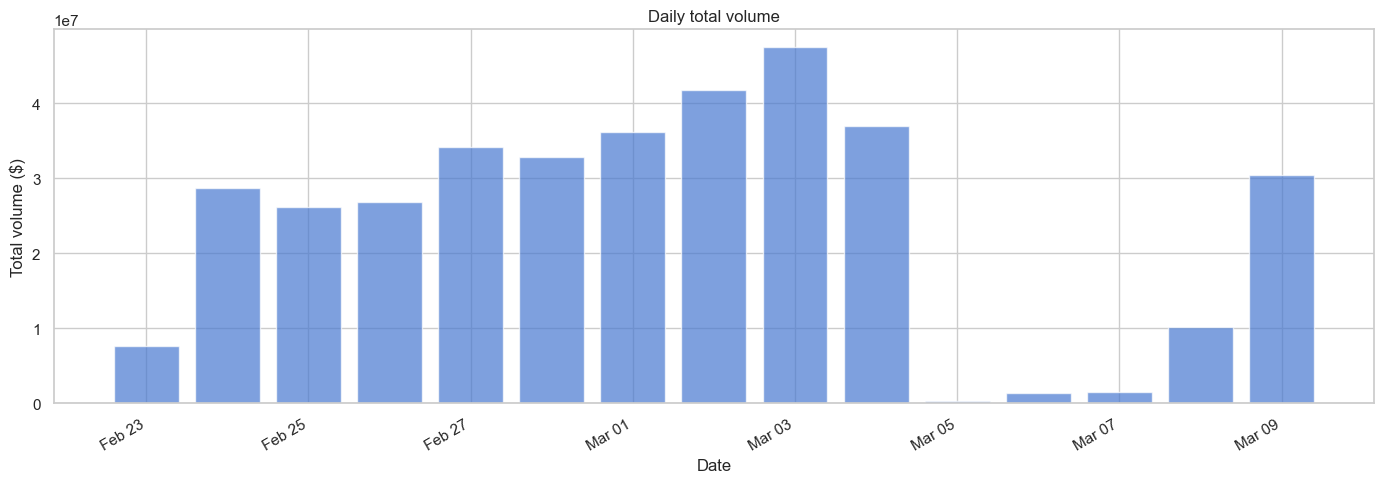

In [24]:
daily_vol = df.groupby("date")["volume"].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(daily_vol.index, daily_vol.values, alpha=0.7)
ax.set_ylabel("Total volume ($)")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate()
ax.set_title("Daily total volume")
plt.tight_layout()
plt.show()

## 5. Temporal patterns

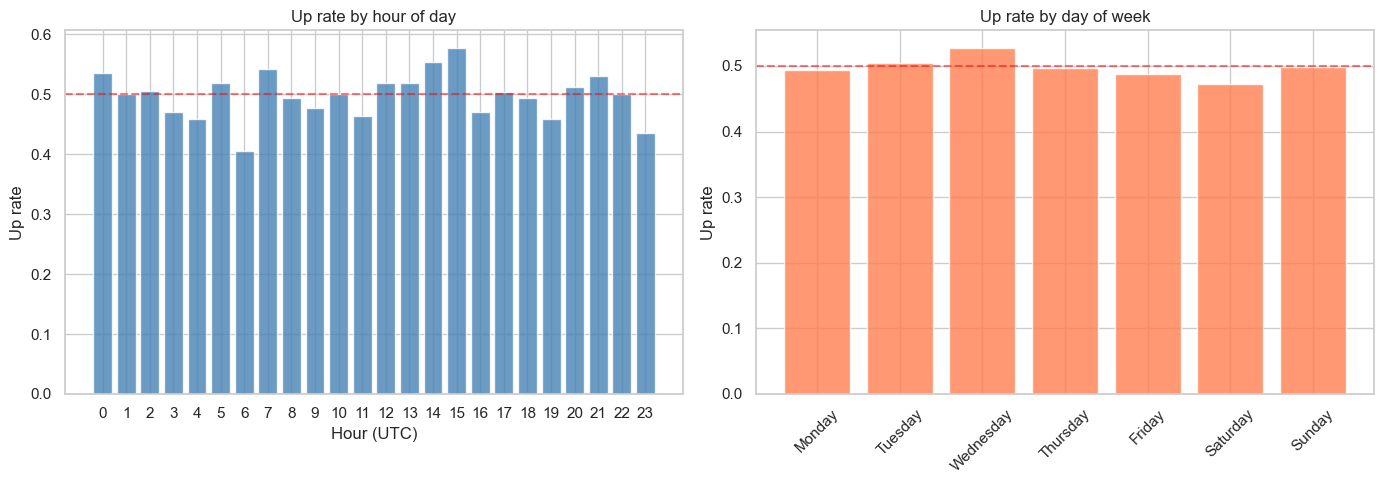

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Up-rate by hour
hourly = df.groupby("hour").agg(
    up_rate=("winner_binary", "mean"),
    count=("winner_binary", "count"),
    avg_volume=("volume", "mean")
)
axes[0].bar(hourly.index, hourly["up_rate"], color="steelblue", alpha=0.8)
axes[0].axhline(0.5, color="red", ls="--", alpha=0.5)
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("Up rate")
axes[0].set_title("Up rate by hour of day")
axes[0].set_xticks(range(0, 24))

# Up-rate by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = df.groupby("day_of_week").agg(
    up_rate=("winner_binary", "mean"),
    count=("winner_binary", "count")
).reindex(day_order)
axes[1].bar(daily.index, daily["up_rate"], color="coral", alpha=0.8)
axes[1].axhline(0.5, color="red", ls="--", alpha=0.5)
axes[1].set_ylabel("Up rate")
axes[1].set_title("Up rate by day of week")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

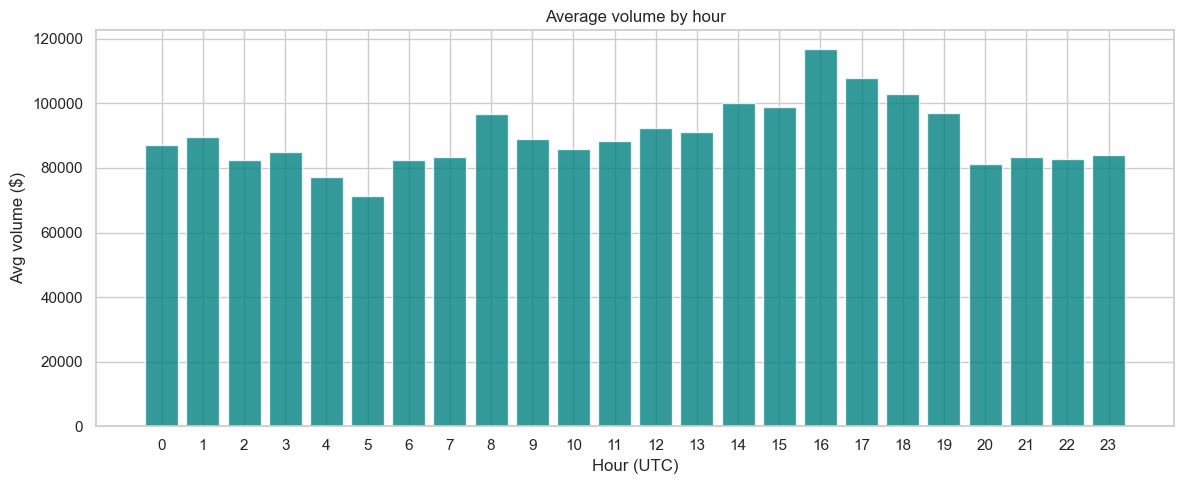

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly.index, hourly["avg_volume"], color="teal", alpha=0.8)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Avg volume ($)")
ax.set_title("Average volume by hour")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 6. Last trade price analysis

The `last_trade_price` reflects the market's final implied probability for "Up".

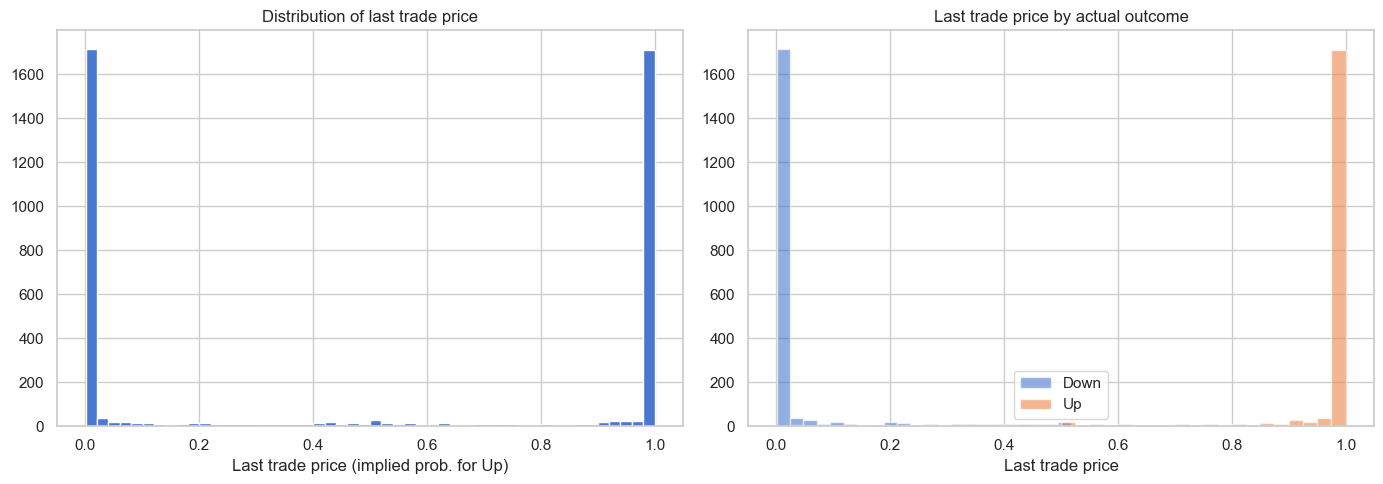

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["last_trade_price"].hist(bins=50, ax=axes[0], edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Distribution of last trade price")
axes[0].set_xlabel("Last trade price (implied prob. for Up)")
axes[0].set_ylabel("Count (log)")

for label, group in df.groupby("winner"):
    axes[1].hist(group["last_trade_price"], bins=40, alpha=0.6, label=label, edgecolor="white")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].set_title("Last trade price by actual outcome")
axes[1].set_xlabel("Last trade price")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()

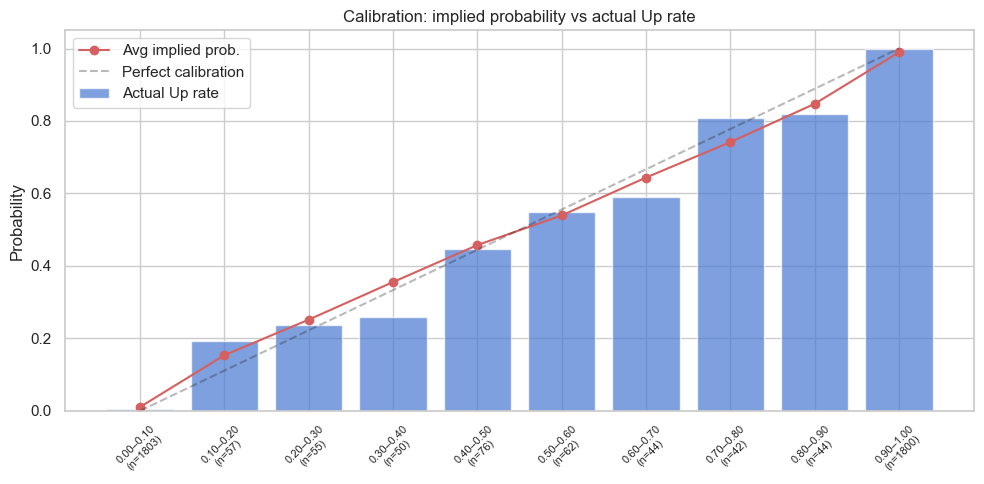

In [12]:
# Calibration: bucket last_trade_price and compare to actual Up rate
df["price_bucket"] = pd.cut(df["last_trade_price"], bins=10)
cal = df.groupby("price_bucket", observed=True).agg(
    actual_up_rate=("winner_binary", "mean"),
    count=("winner_binary", "count"),
    avg_price=("last_trade_price", "mean")
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(cal)), cal["actual_up_rate"], alpha=0.7, label="Actual Up rate")
ax.plot(range(len(cal)), cal["avg_price"], "ro-", label="Avg implied prob.")
ax.plot([0, len(cal)-1], [0, 1], "k--", alpha=0.3, label="Perfect calibration")
ax.set_xticks(range(len(cal)))
ax.set_xticklabels([f"{iv.left:.2f}–{iv.right:.2f}\n(n={n})" for iv, n in zip(cal.index, cal["count"])],
                   fontsize=8, rotation=45)
ax.set_ylabel("Probability")
ax.set_title("Calibration: implied probability vs actual Up rate")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Streaks & autocorrelation

Number of streaks: 2063
Longest Up streak:   10
Longest Down streak: 14
Mean streak length:  1.95


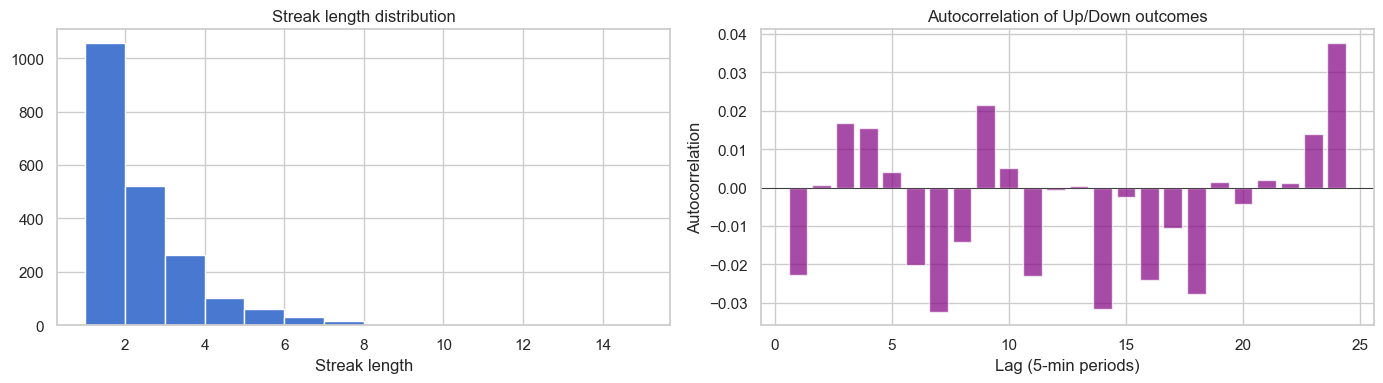

In [13]:
df_sorted = df.sort_values("event_timestamp")
outcomes = df_sorted["winner_binary"].values

# Compute streak lengths
streaks = []
current, length = outcomes[0], 1
for o in outcomes[1:]:
    if o == current:
        length += 1
    else:
        streaks.append(("Up" if current == 1 else "Down", length))
        current, length = o, 1
streaks.append(("Up" if current == 1 else "Down", length))

streak_df = pd.DataFrame(streaks, columns=["direction", "length"])
print(f"Number of streaks: {len(streak_df)}")
print(f"Longest Up streak:   {streak_df[streak_df['direction']=='Up']['length'].max()}")
print(f"Longest Down streak: {streak_df[streak_df['direction']=='Down']['length'].max()}")
print(f"Mean streak length:  {streak_df['length'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

streak_df["length"].hist(bins=range(1, streak_df["length"].max()+2), ax=axes[0], edgecolor="white")
axes[0].set_title("Streak length distribution")
axes[0].set_xlabel("Streak length")

# Autocorrelation of winner_binary
lags = range(1, 25)
autocorrs = [pd.Series(outcomes).autocorr(lag=l) for l in lags]
axes[1].bar(lags, autocorrs, color="purple", alpha=0.7)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Autocorrelation of Up/Down outcomes")
axes[1].set_xlabel("Lag (5-min periods)")
axes[1].set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

## 8. Heatmap: Up rate by hour × day of week

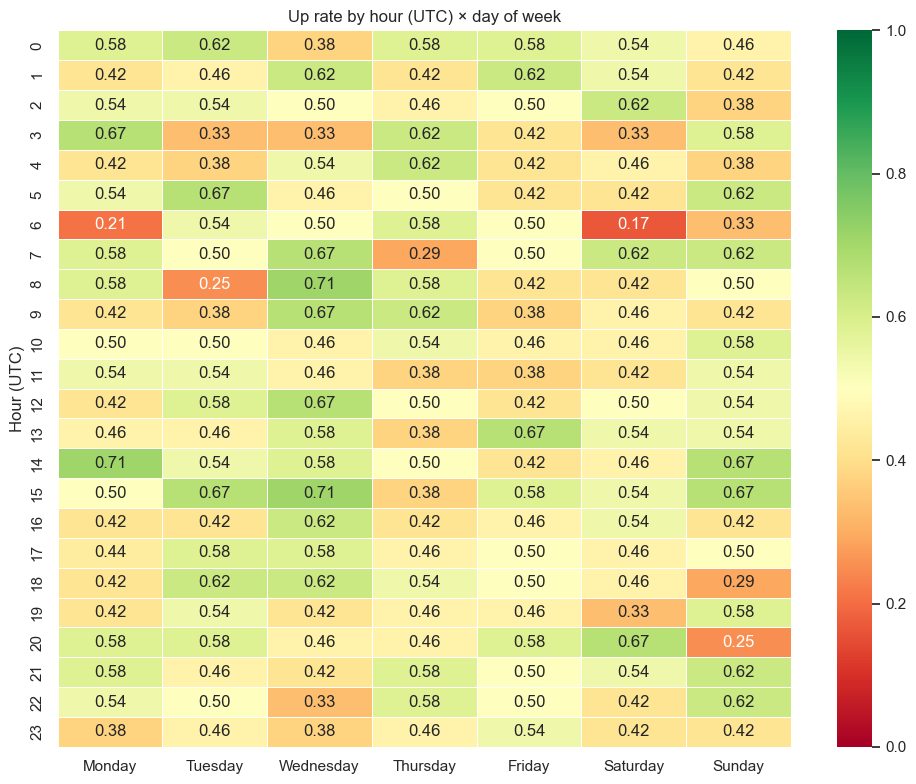

In [14]:
pivot = df.pivot_table(values="winner_binary", index="hour", columns="day_of_week",
                       aggfunc="mean")
pivot = pivot.reindex(columns=day_order)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title("Up rate by hour (UTC) × day of week")
ax.set_ylabel("Hour (UTC)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 9. Rolling Up rate over time

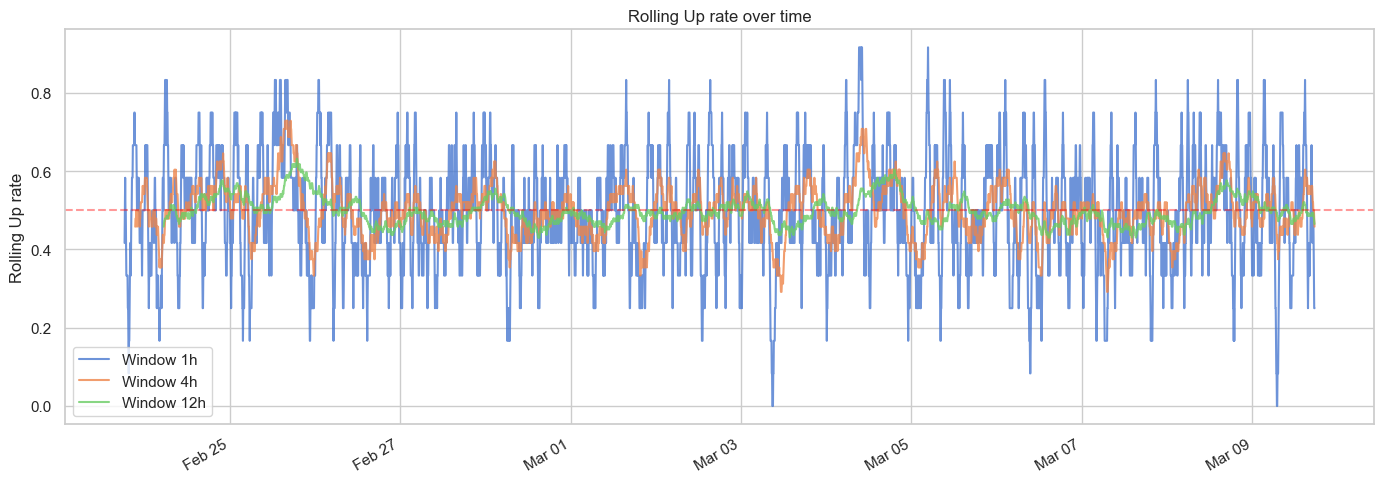

In [15]:
df_sorted = df.sort_values("event_datetime").reset_index(drop=True)

for window in [12, 48, 144]:  # 1h, 4h, 12h
    label = f"{window * 5 // 60}h" if window * 5 >= 60 else f"{window * 5}min"
    df_sorted[f"rolling_up_{label}"] = df_sorted["winner_binary"].rolling(window).mean()

fig, ax = plt.subplots(figsize=(14, 5))
for col in [c for c in df_sorted.columns if c.startswith("rolling_up_")]:
    ax.plot(df_sorted["event_datetime"], df_sorted[col], label=col.replace("rolling_up_", "Window "), alpha=0.8)
ax.axhline(0.5, color="red", ls="--", alpha=0.4)
ax.set_ylabel("Rolling Up rate")
ax.set_title("Rolling Up rate over time")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 10. Key takeaways

In [16]:
print("=== Summary ===")
print(f"Period:            {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Markets:           {len(df):,}")
print(f"Total volume:      ${df['volume'].sum():,.0f}")
print(f"Avg volume/market: ${df['volume'].mean():,.0f}")
print(f"Up rate:           {df['winner_binary'].mean():.1%}")
print(f"All closed:        {df['closed'].all()}")

=== Summary ===
Period:            2026-02-23 to 2026-03-09
Markets:           4,033
Total volume:      $362,449,404
Avg volume/market: $89,871
Up rate:           49.7%
All closed:        True
